# AWBS - Project 1
author: Mateusz Domalewski

group: 2

index: 288761

In [1]:
DATA_2023 = "./data_202302/"
DATA_2021 = "./data_202102/"

import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from datetime import datetime
import sklearn

## Business understanding

### Determining objectives

- Analysis of Internet traffic performance
- Account the download and upload packages
- Incorporate establishing relationships (influences) between parameters refering to Internet traffic performance

### Data mining goals

- Compare Internet traffic performance of dataset from 2023 with the data from 2021
- Clearly present tasks and results. Use tables, charts, diagrams.
- Provide comparative analysis for different prediction algorithms.
- Provide conclusions

### Project Plan

- perform a prediction of a selected parameter related to the performance of Internet traffic
- propose three different, appropriate models for prediction, present their synthetic characteristics, justification for use, limitations, selected set of parameters and their values.


## Data understanding

### Collecting initial data

|dataset|year|link|
|---|---|---|
|data_raw_2023_02| 2023 | https://data.fcc.gov/download/measuring-broadband-america/2023/data-raw-2023-feb.tar.gz |
| data_raw_2021_02 | 2021 | https://data.fcc.gov/download/measuring-broadband-america/2021/data-raw-2021-feb.tar.gz |

### Describing data

#### 2023 upload and dowload

In [2]:
import polars as pl

upload_2023 = pl.read_csv(DATA_2023+"curr_lct_ul.csv")
download_2023 = pl.read_csv(DATA_2023+"curr_lct_dl.csv")

##### **upload 2023**

Generally describing the statistical features of the table

In [3]:
upload_2023.describe()

statistic,unit_id,ddate,dtime,target,address,packets_received,packets_sent,packet_size,bytes_total,duration,bytes_sec,error_code,successes,failures
str,f64,str,str,str,str,f64,f64,f64,f64,f64,f64,str,f64,f64
"""count""",869043.0,"""869043""","""869043""","""869043""","""869043""",869043.0,869043.0,869043.0,869043.0,869043.0,869043.0,"""869043""",869043.0,869043.0
"""null_count""",0.0,"""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0
"""mean""",2.2472e7,null,null,null,null,91.470139,99.272878,1400.0,128058.194589,308216.803378,6.1957e6,null,0.992729,0.007271
"""std""",2.5433e7,null,null,null,null,20.589431,8.49609,0.0,28825.203781,474150.203915,1.4260e7,null,0.084961,0.084961
"""min""",386.0,"""2023-01-31""","""2023-02-01 00:00:03""","""sk-1.uhnet.net""","""0.0.0.0""",0.0,0.0,1400.0,0.0,0.0,0.0,"""EXPORT_ERROR""",0.0,0.0
"""25%""",805922.0,null,null,null,null,100.0,100.0,1400.0,140000.0,19884.0,224069.0,null,1.0,0.0
"""50%""",4.172709e6,null,null,null,null,100.0,100.0,1400.0,140000.0,62963.0,1.95209e6,null,1.0,0.0
"""75%""",3.9486057e7,null,null,null,null,100.0,100.0,1400.0,140000.0,442474.0,6.599104e6,null,1.0,0.0
"""max""",9.3007349e7,"""2023-02-28""","""2023-02-28 23:59:56""","""sp2-vm-newyork-us.samknows.com""","""74.40.74.101""",100.0,100.0,1400.0,140000.0,9.254213e6,7.13207547e8,"""ZERO_RECEIVED_SERVER""",1.0,1.0


- grouping transmissions in 1 hour intervals
- aggregating sum of packets sent
- averaging failures and successes to get their percentages
- transforming the mean out of bytes per second to megabytes per second for the hour

In [4]:
upload_hist = upload_2023.with_columns(pl.col("dtime").str.to_datetime().dt.round("1h"))
upload_hist = upload_hist.group_by(["dtime"]).agg(pl.col("packets_sent").sum(), (pl.col("bytes_sec").mean() / 1_000_000).alias("mbytes_sec"), pl.col(["successes", "failures"]).mean() * 100.0).sort(["dtime"])
upload_hist

dtime,packets_sent,mbytes_sec,successes,failures
datetime[μs],i64,f64,f64,f64
2023-02-01 00:00:00,133000,6.06244,98.884758,1.115242
2023-02-01 01:00:00,279800,5.872537,99.149539,0.850461
2023-02-01 02:00:00,306900,6.212253,99.191984,0.808016
2023-02-01 03:00:00,328700,5.894447,99.215213,0.784787
2023-02-01 04:00:00,337200,5.972213,99.264057,0.735943
…,…,…,…,…
2023-02-28 20:00:00,55800,6.148567,99.642857,0.357143
2023-02-28 21:00:00,55300,6.68533,99.281867,0.718133
2023-02-28 22:00:00,58100,6.347422,98.809524,1.190476


- extracting the columns for `matplotlib` valid format
- plotting the stacked plots of successes and failures for packets transferred
- setting logarithmic scale to account for wide spread
- modifying limits of y axis for best viewing

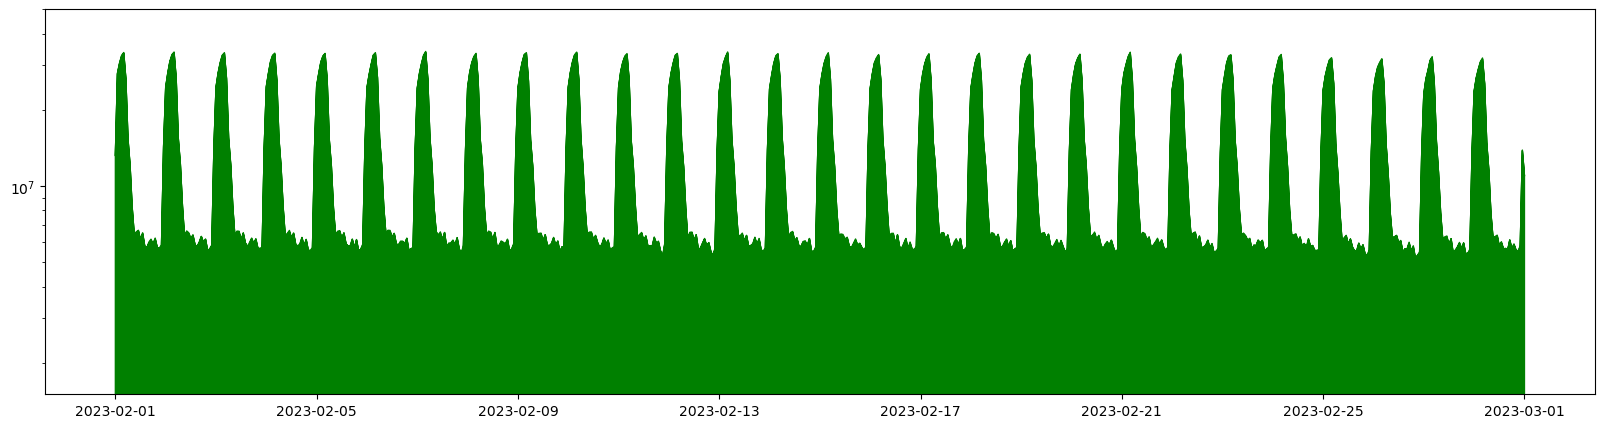

In [5]:
times, packets, mbytes_sec, successes, failures = upload_hist.cast({"dtime" : pl.String}).to_numpy().transpose()

times = times.astype(np.datetime64)

fig, ax = plt.subplots(figsize=[20,5])

stacked = np.array([successes, failures]) * packets

ax.set_ylim(1.5 * 10 ** 6, 5 * 10 ** 7)

ax.set_yscale("log")

ax.stackplot(times, stacked.astype(int), color=["green", "red"])

plt.show()

**conclusion:** almost homogenous success rate - errors are negligible

##### **Download 2023**

Generally describing the statistical features of the table

In [6]:
download_2023.describe()

statistic,unit_id,ddate,dtime,target,address,packets_received,packets_sent,packet_size,bytes_total,duration,bytes_sec,error_code,successes,failures
str,f64,str,str,str,str,f64,f64,f64,f64,f64,f64,str,f64,f64
"""count""",869701.0,"""869701""","""869701""","""869701""","""869701""",869701.0,869701.0,869701.0,869701.0,869701.0,869701.0,"""869701""",869701.0,869701.0
"""null_count""",0.0,"""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0
"""mean""",2.2410e7,null,null,null,null,86.66543,99.667242,1400.0,121331.60178,33574.694549,3.1210e7,null,0.996672,0.003328
"""std""",2.5417e7,null,null,null,null,20.926162,5.758916,0.0,29296.626978,107545.596092,3.5901e7,null,0.057589,0.057589
"""min""",386.0,"""2023-01-31""","""2023-02-01 00:00:00""","""sk-1.uhnet.net""","""0.0.0.0""",0.0,0.0,1400.0,0.0,0.0,0.0,"""NO_ERROR""",0.0,0.0
"""25%""",805804.0,null,null,null,null,77.0,100.0,1400.0,107800.0,5606.0,4.770858e6,null,1.0,0.0
"""50%""",4.172669e6,null,null,null,null,100.0,100.0,1400.0,140000.0,9491.0,1.371387e7,null,1.0,0.0
"""75%""",3.9486017e7,null,null,null,null,100.0,100.0,1400.0,140000.0,23817.0,4.5768056e7,null,1.0,0.0
"""max""",9.3007349e7,"""2023-02-28""","""2023-02-28 23:59:59""","""sp2-vm-newyork-us.samknows.com""","""96.99.224.233""",100.0,100.0,1400.0,140000.0,3.004544e6,3.248e8,"""ZERO_SENT_SERVER""",1.0,1.0


- grouping transmissions in 1 hour intervals
- aggregating sum of packets sent
- averaging failures and successes to get their percentages
- transforming the mean out of bytes per second to megabytes per second for the hour

In [7]:
dwload_hist = download_2023.with_columns(pl.col("dtime").str.to_datetime().dt.round("1h"))
dwload_hist = dwload_hist.group_by(["dtime"]).agg(pl.col("packets_sent").sum(), (pl.col("bytes_sec").mean() / 1_000_000).alias("mbytes_sec"), pl.col(["successes", "failures"]).mean() * 100.0).sort(["dtime"])
dwload_hist

dtime,packets_sent,mbytes_sec,successes,failures
datetime[μs],i64,f64,f64,f64
2023-02-01 00:00:00,135300,31.365133,99.558499,0.441501
2023-02-01 01:00:00,280500,30.806859,99.53868,0.46132
2023-02-01 02:00:00,308300,30.913645,99.580103,0.419897
2023-02-01 03:00:00,334700,29.908655,99.494649,0.505351
2023-02-01 04:00:00,341800,30.773184,99.708285,0.291715
…,…,…,…,…
2023-02-28 20:00:00,56400,30.877067,99.646643,0.353357
2023-02-28 21:00:00,55700,32.925269,99.464286,0.535714
2023-02-28 22:00:00,58100,29.009264,99.486301,0.513699


- extracting the columns for `matplotlib` valid format
- plotting the stacked plots of successes and failures for packets transferred
- setting logarithmic scale to account for wide spread
- modifying limits of y axis for best viewing

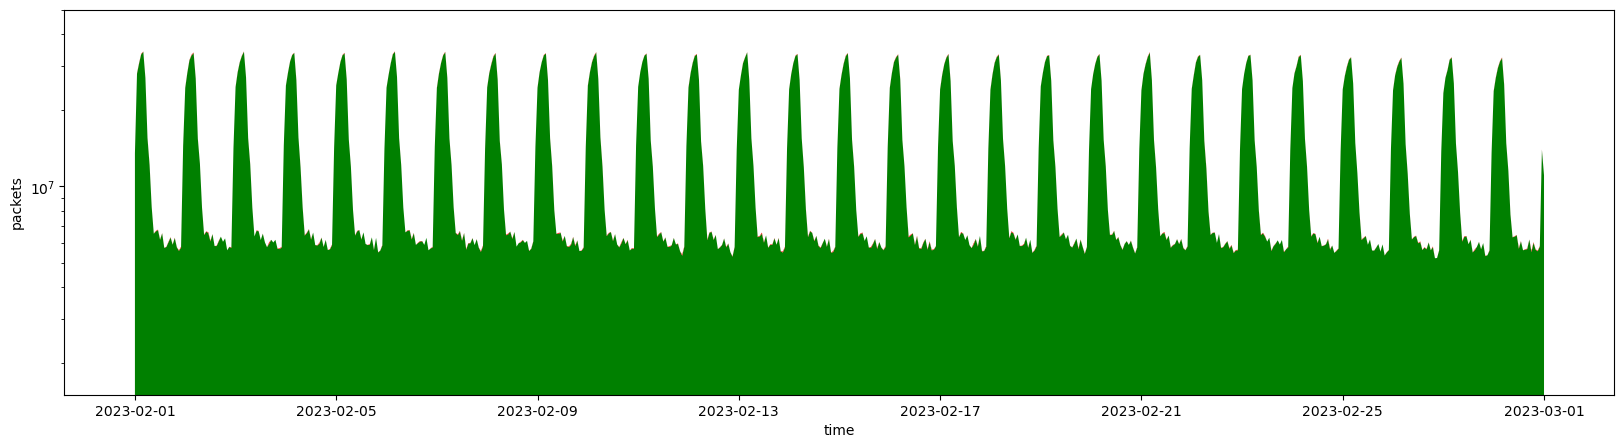

In [8]:
times, packets, mbytes_sec, successes, failures = dwload_hist.cast({"dtime" : pl.String}).to_numpy().transpose()

times = times.astype(np.datetime64)

fig, ax = plt.subplots(figsize=[20,5])

stacked = np.array([successes, failures]) * packets

ax.set_xlabel("time")

ax.set_ylabel("packets")

ax.set_ylim(1.5 * 10 ** 6, 5 * 10 ** 7)

ax.set_yscale("log")

ax.stackplot(times, stacked.astype(int), colors=["green", "red"])

plt.show()

**conclusion:** again near homogenous success rate - errors are negligible

#### Possibly interesting datasets from 2023

##### **Upload ping**

In [9]:
ul_ping = pl.read_csv(DATA_2023+"curr_ulping.csv")

Generally describing the statistical features of the ping table (see that hosts may match to primary tables)

In [10]:
ul_ping.describe()

statistic,unit_id,dtime,target,rtt_avg,rtt_min,rtt_max,rtt_std,successes,failures
str,f64,str,str,f64,f64,f64,f64,f64,f64
"""count""",1.260944e6,"""1260944""","""1260944""",1.260944e6,1.260944e6,1.260944e6,1.260944e6,1.260944e6,1.260944e6
"""null_count""",0.0,"""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",2.3270e7,null,null,246504.206554,25685.968431,368149.587011,69536.47149,131.431135,8.57364
"""std""",2.5577e7,null,null,436911.773699,52241.127707,592335.0741,149473.353031,202.881023,26.916415
"""min""",386.0,"""2023-02-01 00:00:00""","""01-on-regional-albuquerque.sam…",0.0,0.0,0.0,0.0,0.0,0.0
"""25%""",806008.0,null,null,28088.0,9871.0,53384.0,5252.0,116.0,0.0
"""50%""",2.4525377e7,null,null,59956.0,16179.0,143171.0,19143.0,143.0,0.0
"""75%""",3.9486401e7,null,null,244234.0,28518.0,364661.0,54473.0,151.0,4.0
"""max""",9.3007349e7,"""2023-02-28 23:59:59""","""whplny-1-on.cv.net""",2.995536e6,2.995536e6,2.999999e6,1.518446e6,159510.0,1378.0


checking for matching records for extablished targets

In [11]:
ulp_data = ul_ping.group_by("target").agg(pl.col("target").unique_counts().alias("data_amount"))
common_targets = upload_2023.select("target").unique().join(ulp_data, how="left", on="target").sort("data_amount", descending=True)
common_targets

target,data_amount
str,list[u32]
"""sp1-vm-chicago-us.samknows.com""",[91995]
"""sp2-vm-chicago-us.samknows.com""",[85887]
"""sp1-vm-ashburn-us.samknows.com""",[80260]
"""sp1-vm-atlanta-us.samknows.com""",[69373]
"""sp1-vm-losangeles-us.samknows.…",[64950]
…,…
"""sp1-vm-denver-us.samknows.com""",[38760]
"""sp1-vm-sanjose-us.samknows.com""",[35721]
"""sp1-vm-miami-us.samknows.com""",[29758]


**Conclusion:** table can be joined with the upload table to provide more insights

##### **Download ping**

In [12]:
dl_ping = pl.read_csv(DATA_2023+"curr_dlping.csv")

Generally describing the statistical features of the ping table (see that hosts may match to primary tables again)

In [13]:
dl_ping.describe()

statistic,unit_id,dtime,target,rtt_avg,rtt_min,rtt_max,rtt_std,successes,failures
str,f64,str,str,f64,f64,f64,f64,f64,f64
"""count""",1.246832e6,"""1246832""","""1246832""",1.246832e6,1.246832e6,1.246832e6,1.246832e6,1.246832e6,1.246832e6
"""null_count""",0.0,"""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",2.3139e7,null,null,105448.482533,23554.363431,190590.062653,41161.446109,149.791145,5.984578
"""std""",2.5552e7,null,null,199475.926837,41634.751442,372684.883975,97133.519491,656.420056,236.331869
"""min""",386.0,"""2023-02-01 00:00:00""","""01-on-regional-albuquerque.sam…",0.0,0.0,0.0,0.0,0.0,0.0
"""25%""",805700.0,null,null,21505.0,8566.0,33583.0,3573.0,123.0,0.0
"""50%""",2.4328809e7,null,null,42594.0,14618.0,69319.0,8641.0,141.0,0.0
"""75%""",3.9486317e7,null,null,95253.0,27280.0,162710.0,28391.0,164.0,2.0
"""max""",9.3007349e7,"""2023-02-28 23:59:58""","""whplny-1-on.cv.net""",2.846991e6,2.71029e6,2.999992e6,1.548048e6,430309.0,140604.0


checking for matching records for extablished targets

In [14]:
dlp_data = dl_ping.group_by("target").agg(pl.col("target").unique_counts().alias("data_amount"))
common_targets = download_2023.select("target").unique().join(dlp_data, how="left", on="target").sort("data_amount", descending=True)
common_targets

target,data_amount
str,list[u32]
"""sp1-vm-chicago-us.samknows.com""",[90972]
"""sp2-vm-chicago-us.samknows.com""",[85470]
"""sp1-vm-ashburn-us.samknows.com""",[79590]
"""sp1-vm-atlanta-us.samknows.com""",[68792]
"""sp1-vm-losangeles-us.samknows.…",[64396]
…,…
"""sp1-vm-denver-us.samknows.com""",[38338]
"""sp1-vm-sanjose-us.samknows.com""",[35307]
"""sp1-vm-miami-us.samknows.com""",[29430]


**Conclusion:** table can be joined with the upload table to provide more insights

## Data preparation

### Upload averages

alternative data approach - sorting by host and averaging successes and failures

In [15]:
up_avgs = upload_2023.group_by(["target"], maintain_order=True).agg(pl.col("packets_sent").mean().name.suffix("_mean"), pl.col("packets_sent").std().name.suffix("_stdev"), (pl.col("successes").mean() * 100).name.suffix("_pct"), (pl.col("failures").mean() * 100).name.suffix("_pct") )

up_avgs = up_avgs.sort("target").fill_null(0.0)

up_avgs

target,packets_sent_mean,packets_sent_stdev,successes_pct,failures_pct
str,f64,f64,f64,f64
"""sk-1.uhnet.net""",99.183511,8.999462,99.183511,0.816489
"""sp1-vm-ashburn-us.samknows.com""",99.187515,8.977155,99.187515,0.812485
"""sp1-vm-atlanta-us.samknows.com""",99.509582,6.98583,99.509582,0.490418
"""sp1-vm-chicago-us.samknows.com""",99.143512,9.214987,99.143512,0.856488
"""sp1-vm-dallas-us.samknows.com""",99.18698,8.980102,99.18698,0.81302
…,…,…,…,…
"""sp1-vm-sanjose-us.samknows.com""",98.990189,9.998188,98.990189,1.009811
"""sp1-vm-seattle-us.samknows.com""",99.565673,6.576074,99.565673,0.434327
"""sp2-vm-ashburn-us.samknows.com""",92.857143,26.226526,92.857143,7.142857


looking for significant outliers in packets sent and error rate

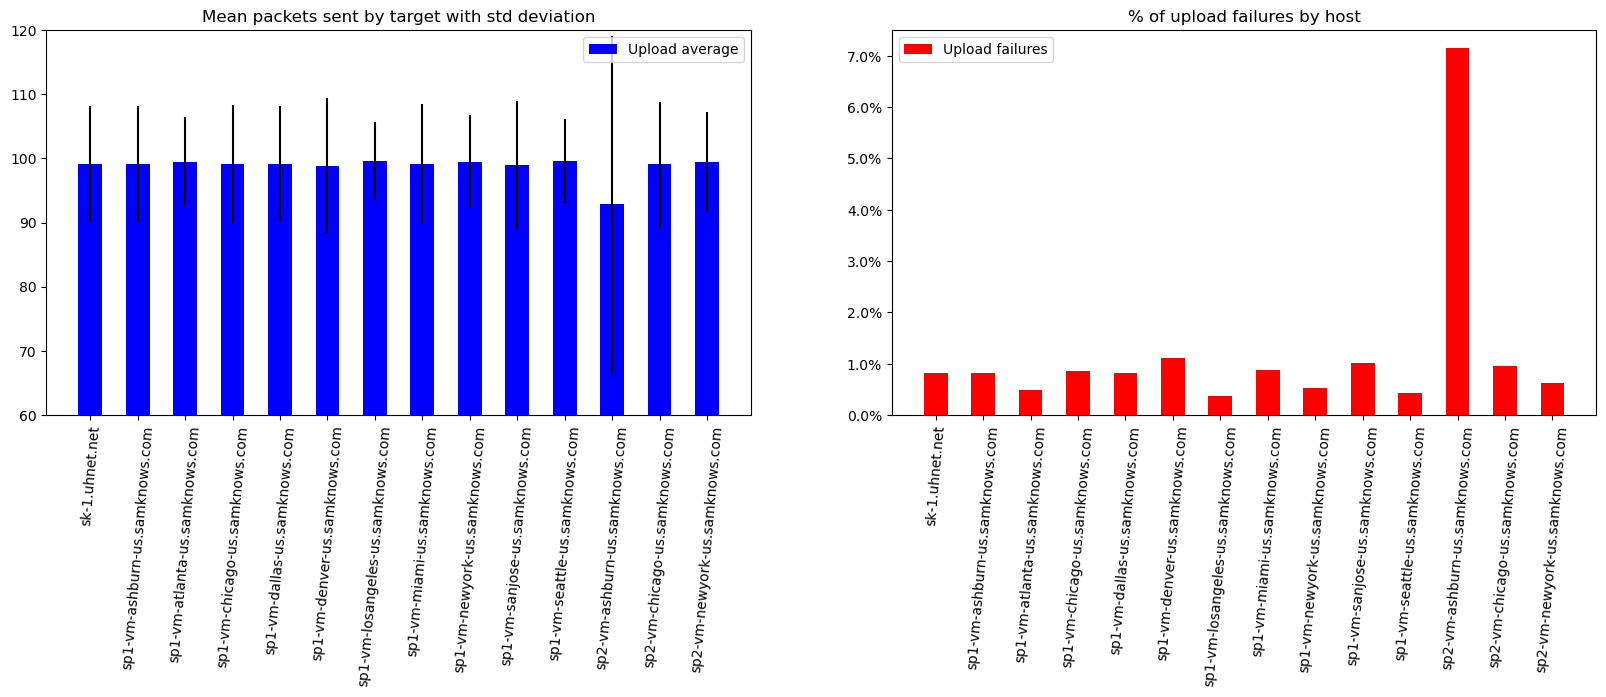

In [16]:
targets, up_means, up_stdev, up_oks, up_fails = up_avgs.to_numpy().transpose()


fig, ax = plt.subplots(1, 2, figsize=[20,5])

# means
ax[0].bar(targets, up_means, width=0.5, yerr=up_stdev, label="Upload average", color="blue")
ax[0].set_ylim(60.0, 120.0)
ax[0].set_title("Mean packets sent by target with std deviation")

# failures

ax[1].bar(targets, up_fails, width=0.5, label="Upload failures", color="red")
ax[1].yaxis.set_major_formatter(ticker.PercentFormatter())
ax[1].set_title("% of upload failures by host")

for i in range(len(ax)):
    ax[i].legend()
    ax[i].autoscale_view()
    ax[i].tick_params(axis="x", rotation=85)

plt.show()

**Conclusion:** acceptable values range and error rates (the outlier has small sample size hence the results)

### Upload errors

looking for significant outliers in packets sent error types

In [17]:
errors = upload_2023.group_by(["target", "error_code"]).agg(pl.col("error_code").count().alias("amount"))

errors = errors.join(upload_2023.group_by("target").agg(pl.col("failures").sum().alias("total")), how="left", on="target")

errors = errors.with_columns(amount_pct = pl.col("amount") * 100 / pl.col("total"))

errors = errors.pivot(on="error_code", index="target", values="amount_pct").drop("NO_ERROR").fill_null(0.0).sort("target")

errors

target,JSON_PARSE_ERROR,ZERO_RECEIVED_SERVER,RCV_FAILED,SEND_FAILED,TCP_CONNECT,EXPORT_ERROR,TCP_RECV
str,f64,f64,f64,f64,f64,f64,f64
"""sk-1.uhnet.net""",2.439024,15.853659,29.268293,0.0,52.439024,0.0,0.0
"""sp1-vm-ashburn-us.samknows.com""",2.18281,1.091405,6.548431,7.230559,82.946794,0.0,0.0
"""sp1-vm-atlanta-us.samknows.com""",3.781513,2.941176,10.714286,13.445378,68.907563,0.210084,0.0
"""sp1-vm-chicago-us.samknows.com""",2.35546,1.927195,3.640257,20.449679,71.627409,0.0,0.0
"""sp1-vm-dallas-us.samknows.com""",15.779817,2.752294,10.642202,1.651376,69.174312,0.0,0.0
…,…,…,…,…,…,…,…
"""sp1-vm-sanjose-us.samknows.com""",53.317536,3.791469,8.056872,6.161137,28.672986,0.0,0.0
"""sp1-vm-seattle-us.samknows.com""",8.865248,6.382979,9.219858,0.0,75.531915,0.0,0.0
"""sp2-vm-ashburn-us.samknows.com""",0.0,50.0,50.0,0.0,0.0,0.0,0.0


14


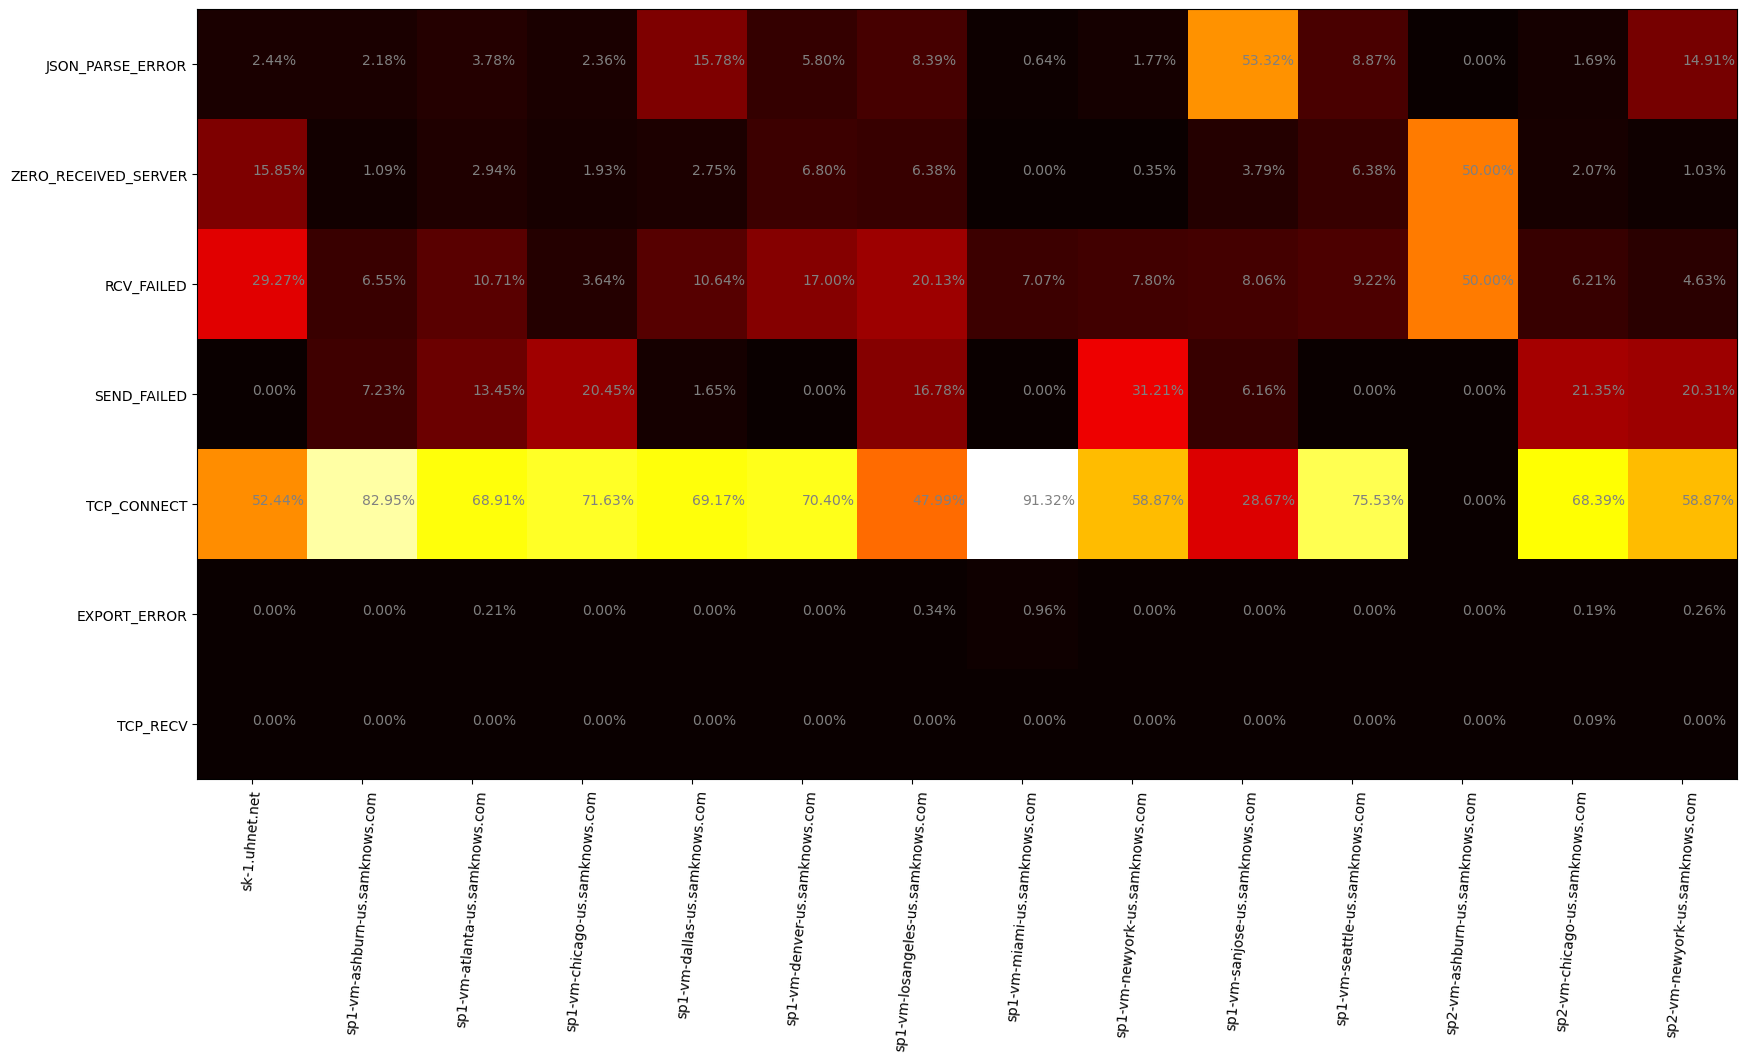

In [18]:
err_types = errors.columns[1:]

targets = errors.to_numpy().transpose()
values = targets[1:].astype(float)
targets = targets[0]

print(len(targets))

fig, ax = plt.subplots(figsize = [25, 10])
ax.imshow(values, cmap="hot")
ax.set_xticks(range(len(targets)), labels=targets, rotation=85)
ax.set_yticks(range(len(err_types)), labels=err_types)

for x in range(len(targets)):
    for y in range(len(err_types)):
        ax.text(x, y, f"{values[y][x]:.2f}%", color="gray")

plt.show()

**Conclusion:** again acceptable outcome

only possible outlier is ashburn but only due to small target sample size

### Download averages

again - alternative data approach - sorting by host and averaging successes and failures

In [19]:
dw_avgs = download_2023.group_by(["target"], maintain_order=True).agg(pl.col("packets_received").mean().name.suffix("_mean"), pl.col("packets_received").std().name.suffix("_stdev"), (pl.col("successes").mean() * 100).name.suffix("_pct"), (pl.col("failures").mean() * 100).name.suffix("_pct") )

dw_avgs = dw_avgs.sort("target").fill_null(0.0)

dw_avgs

target,packets_received_mean,packets_received_stdev,successes_pct,failures_pct
str,f64,f64,f64,f64
"""sk-1.uhnet.net""",91.126478,16.719704,99.513164,0.486836
"""sp1-vm-ashburn-us.samknows.com""",89.157478,18.943243,99.701347,0.298653
"""sp1-vm-atlanta-us.samknows.com""",87.476392,19.428849,99.663918,0.336082
"""sp1-vm-chicago-us.samknows.com""",84.214081,22.357806,99.675108,0.324892
"""sp1-vm-dallas-us.samknows.com""",88.259337,19.594169,99.710772,0.289228
…,…,…,…,…
"""sp1-vm-sanjose-us.samknows.com""",90.522035,18.668834,99.103771,0.896229
"""sp1-vm-seattle-us.samknows.com""",83.70247,23.118496,99.685675,0.314325
"""sp2-vm-ashburn-us.samknows.com""",85.392857,21.615048,100.0,0.0


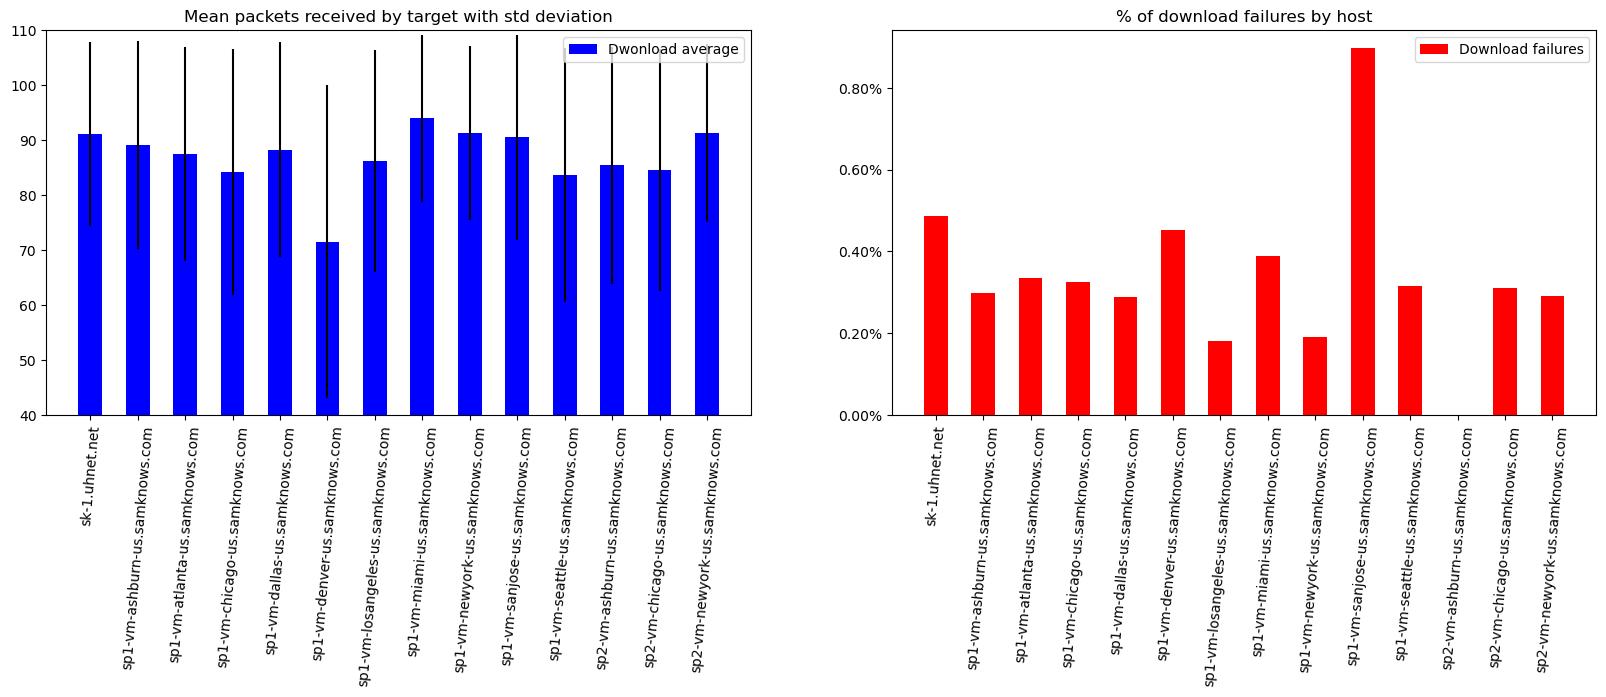

In [20]:
targets, dw_means, dw_stdev, dw_oks, dw_fails = dw_avgs.to_numpy().transpose()


fig, ax = plt.subplots(1, 2, figsize=[20,5])

# means
ax[0].bar(targets, dw_means, width=0.5, yerr=dw_stdev, label="Dwonload average", color="blue")
ax[0].set_ylim(40.0, 110.0)
ax[0].set_title("Mean packets received by target with std deviation")

# failures

ax[1].bar(targets, dw_fails, width=0.5, label="Download failures", color="red")
ax[1].yaxis.set_major_formatter(ticker.PercentFormatter())
ax[1].set_title("% of download failures by host")

for i in range(len(ax)):
    ax[i].legend()
    ax[i].autoscale_view()
    ax[i].tick_params(axis="x", rotation=85)

plt.show()

**Conclusion:** acceptable values range and very small erro percentages

### Download errors

looking for significant outliers in packets sent error types

In [21]:
errors = download_2023.group_by(["target", "error_code"]).agg(pl.col("error_code").count().alias("amount"))

errors = errors.join(upload_2023.group_by("target").agg(pl.col("failures").sum().alias("total")), how="left", on="target")

errors = errors.with_columns(amount_pct = pl.col("amount") * 100 / pl.col("total"))

errors = errors.pivot(on="error_code", index="target", values="amount_pct").drop("NO_ERROR").fill_null(0.0).sort("target")

errors

target,TCP_CONNECT,RCV_FAILED,ZERO_SENT_SERVER,TCP_RECV
str,f64,f64,f64,f64
"""sk-1.uhnet.net""",50.0,8.536585,1.219512,0.0
"""sp1-vm-ashburn-us.samknows.com""",34.652115,1.637108,0.545703,0.0
"""sp1-vm-atlanta-us.samknows.com""",59.663866,4.201681,4.621849,0.0
"""sp1-vm-chicago-us.samknows.com""",34.689507,1.498929,1.820128,0.0
"""sp1-vm-dallas-us.samknows.com""",28.807339,3.853211,2.93578,0.0
…,…,…,…,…
"""sp1-vm-sanjose-us.samknows.com""",32.938389,4.50237,51.421801,0.0
"""sp1-vm-seattle-us.samknows.com""",66.312057,4.609929,1.41844,0.0
"""sp2-vm-ashburn-us.samknows.com""",0.0,0.0,0.0,0.0


14


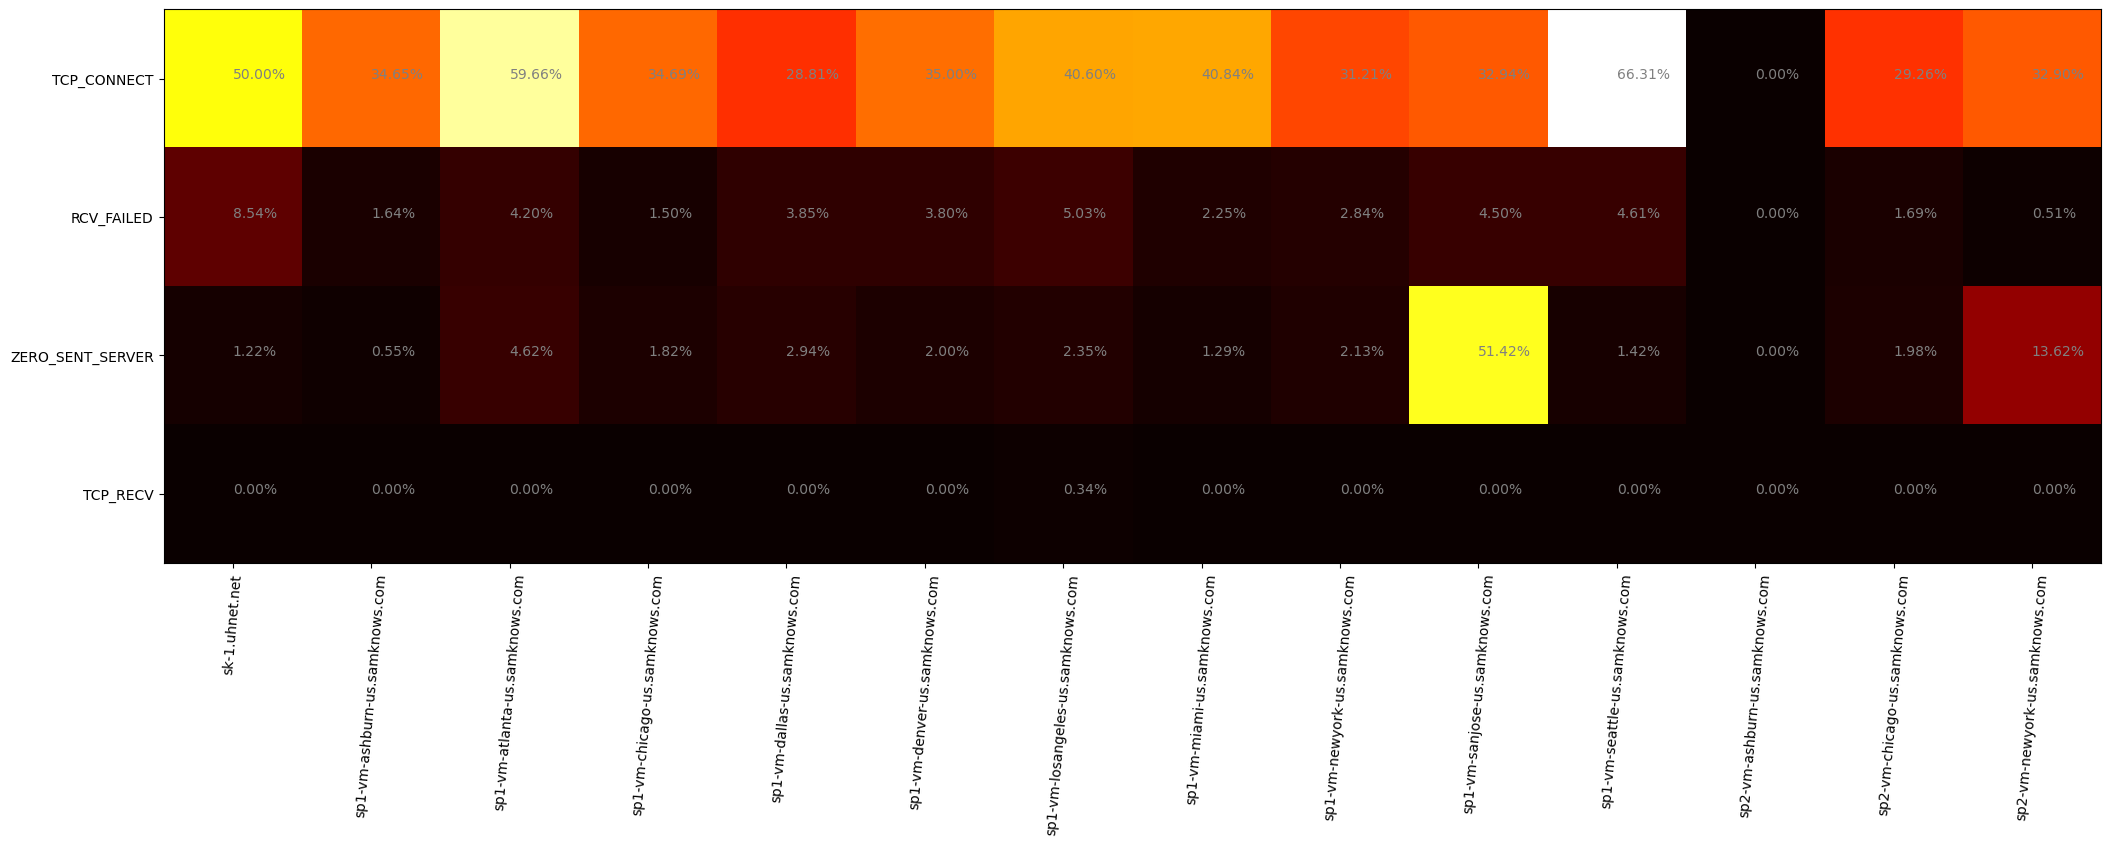

In [22]:
err_types = errors.columns[1:]

targets = errors.to_numpy().transpose()
values = targets[1:].astype(float)
targets = targets[0]

print(len(targets))

fig, ax = plt.subplots(figsize = [25, 10])
ax.imshow(values, cmap="hot")
ax.set_xticks(range(len(targets)), labels=targets, rotation=85)
ax.set_yticks(range(len(err_types)), labels=err_types)

for x in range(len(targets)):
    for y in range(len(err_types)):
        ax.text(x, y, f"{values[y][x]:.2f}%", color="gray")

plt.show()

**Conclusion:** again acceptable outcome

no singly dominant error type, again can be discarded also due to small error percentages

### Joining with pings (target averages)

working on the discovered relation between targets to extablish a more complete table

In [23]:
rtts = ul_ping.group_by("target").agg(pl.col("rtt_avg").mean() / 1_000)

ul_enhanced = up_avgs.join(rtts, how="left", on="target")

ul_enhanced

target,packets_sent_mean,packets_sent_stdev,successes_pct,failures_pct,rtt_avg
str,f64,f64,f64,f64,f64
"""sk-1.uhnet.net""",99.183511,8.999462,99.183511,0.816489,328.618186
"""sp1-vm-ashburn-us.samknows.com""",99.187515,8.977155,99.187515,0.812485,254.512642
"""sp1-vm-atlanta-us.samknows.com""",99.509582,6.98583,99.509582,0.490418,299.22753
"""sp1-vm-chicago-us.samknows.com""",99.143512,9.214987,99.143512,0.856488,285.558082
"""sp1-vm-dallas-us.samknows.com""",99.18698,8.980102,99.18698,0.81302,278.584586
…,…,…,…,…,…
"""sp1-vm-sanjose-us.samknows.com""",98.990189,9.998188,98.990189,1.009811,185.764202
"""sp1-vm-seattle-us.samknows.com""",99.565673,6.576074,99.565673,0.434327,355.396155
"""sp2-vm-ashburn-us.samknows.com""",92.857143,26.226526,92.857143,7.142857,110.064333


In [24]:
rtts = dl_ping.group_by("target").agg(pl.col("rtt_avg").mean() / 1_000)

dw_enhanced = dw_avgs.join(rtts, how="left", on="target")

dw_enhanced

target,packets_received_mean,packets_received_stdev,successes_pct,failures_pct,rtt_avg
str,f64,f64,f64,f64,f64
"""sk-1.uhnet.net""",91.126478,16.719704,99.513164,0.486836,143.599202
"""sp1-vm-ashburn-us.samknows.com""",89.157478,18.943243,99.701347,0.298653,113.549951
"""sp1-vm-atlanta-us.samknows.com""",87.476392,19.428849,99.663918,0.336082,89.129472
"""sp1-vm-chicago-us.samknows.com""",84.214081,22.357806,99.675108,0.324892,109.69154
"""sp1-vm-dallas-us.samknows.com""",88.259337,19.594169,99.710772,0.289228,98.524351
…,…,…,…,…,…
"""sp1-vm-sanjose-us.samknows.com""",90.522035,18.668834,99.103771,0.896229,81.997816
"""sp1-vm-seattle-us.samknows.com""",83.70247,23.118496,99.685675,0.314325,110.711638
"""sp2-vm-ashburn-us.samknows.com""",85.392857,21.615048,100.0,0.0,44.169667


**conclusion:** joining tables can provide valuable data insights into upload and download data however the vast difference of data samples per host makes it harder to execute

### Joining with pings (time)

attempting to enhance time based results with the data from ping datasets

- aggregating upload ping time by the hour period
- enhancing the previous upload table with generated results
- presenting excerpts as table

In [25]:
ul_ping_hist = ul_ping.with_columns(pl.col("dtime").str.to_datetime().dt.round("1h")).group_by("dtime").agg(pl.col("rtt_avg").mean())
ul_hist = upload_hist.join(ul_ping_hist, how="left", on="dtime")

ul_hist

dtime,packets_sent,mbytes_sec,successes,failures,rtt_avg
datetime[μs],i64,f64,f64,f64,f64
2023-02-01 00:00:00,133000,6.06244,98.884758,1.115242,243813.016393
2023-02-01 01:00:00,279800,5.872537,99.149539,0.850461,243688.513748
2023-02-01 02:00:00,306900,6.212253,99.191984,0.808016,244930.318381
2023-02-01 03:00:00,328700,5.894447,99.215213,0.784787,252465.801685
2023-02-01 04:00:00,337200,5.972213,99.264057,0.735943,262563.26125
…,…,…,…,…,…
2023-02-28 20:00:00,55800,6.148567,99.642857,0.357143,189050.12135
2023-02-28 21:00:00,55300,6.68533,99.281867,0.718133,248595.806414
2023-02-28 22:00:00,58100,6.347422,98.809524,1.190476,260861.574556


producing a graph overlaying the packet amount, averages as well as roundtrip times

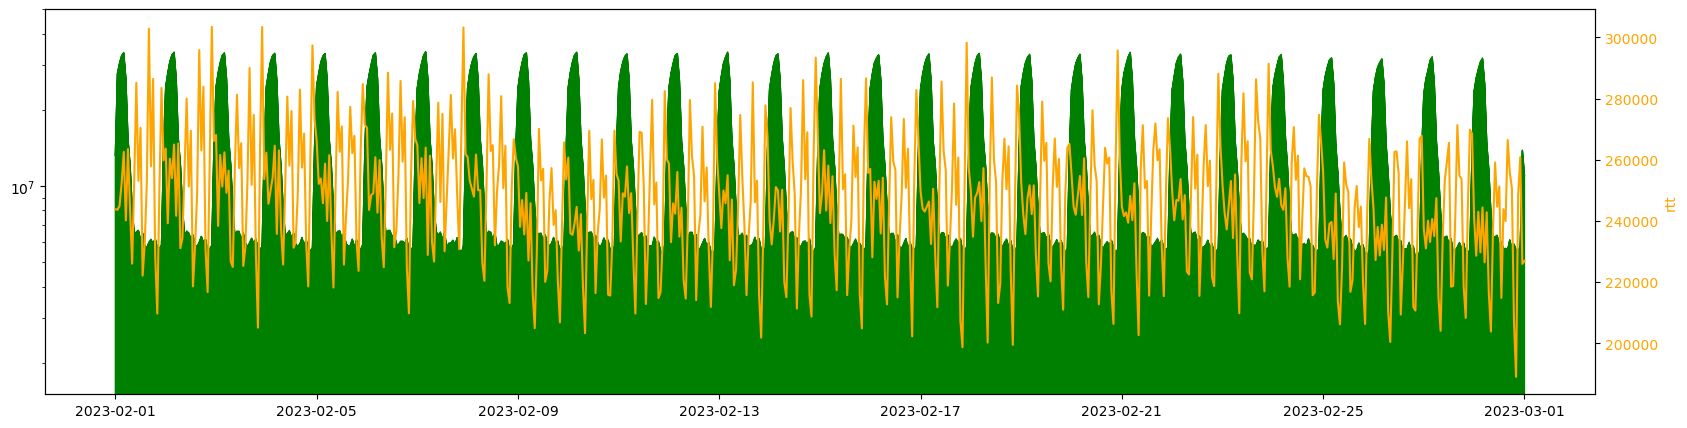

In [26]:
times, packets, mbytes_sec, successes, failures, rtt = ul_hist.cast({"dtime" : pl.String}).to_numpy().transpose()

times = times.astype(np.datetime64)

fig, ax = plt.subplots(figsize=[20,5])

stacked = np.array([successes, failures]) * packets

ax2 = ax.twinx()

ax2.errorbar(times, rtt, color="orange")

ax2.set_ylabel("rtt", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")

ax.set_ylim(1.5 * 10 ** 6, 5 * 10 ** 7)

ax.set_yscale("log")

ax.stackplot(times, stacked.astype(int), color=["green", "red"])

plt.show()

- aggregating ping time by the hour period (download ping now)
- enhancing the previous upload table with generated results
- presenting important columns as table

In [27]:
dw_ping_hist = dl_ping.with_columns(pl.col("dtime").str.to_datetime().dt.round("1h")).group_by("dtime").agg(pl.col("rtt_avg").mean())
dw_hist = dwload_hist.join(dw_ping_hist, how="left", on="dtime")

dw_hist

dtime,packets_sent,mbytes_sec,successes,failures,rtt_avg
datetime[μs],i64,f64,f64,f64,f64
2023-02-01 00:00:00,135300,31.365133,99.558499,0.441501,110318.778198
2023-02-01 01:00:00,280500,30.806859,99.53868,0.46132,103990.551909
2023-02-01 02:00:00,308300,30.913645,99.580103,0.419897,106593.86908
2023-02-01 03:00:00,334700,29.908655,99.494649,0.505351,97589.405055
2023-02-01 04:00:00,341800,30.773184,99.708285,0.291715,112987.076756
…,…,…,…,…,…
2023-02-28 20:00:00,56400,30.877067,99.646643,0.353357,96579.211483
2023-02-28 21:00:00,55700,32.925269,99.464286,0.535714,97468.682243
2023-02-28 22:00:00,58100,29.009264,99.486301,0.513699,113390.907873


producing a graph overlaying the packet amount, averages as well as roundtrip times (for downloads)

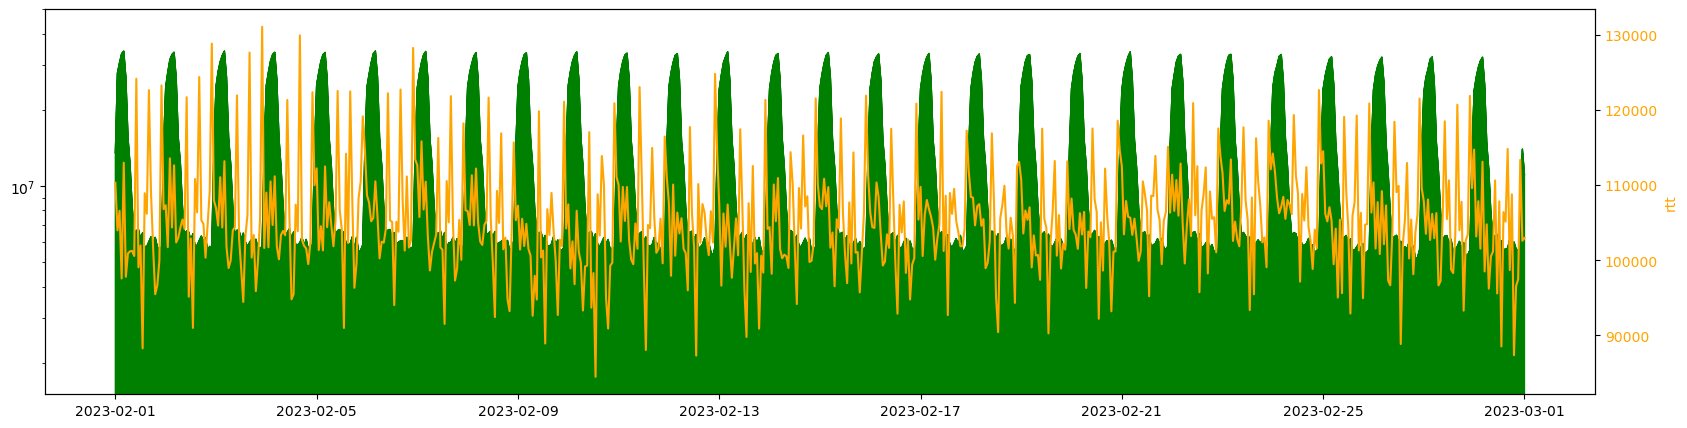

In [28]:
times, packets, mbytes_sec, successes, failures, rtt = dw_hist.cast({"dtime" : pl.String}).to_numpy().transpose()

times = times.astype(np.datetime64)

fig, ax = plt.subplots(figsize=[20,5])

stacked = np.array([successes, failures]) * packets

ax2 = ax.twinx()

ax2.errorbar(times, rtt, color="orange")

ax2.set_ylabel("rtt", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")

ax.set_ylim(1.5 * 10 ** 6, 5 * 10 ** 7)

ax.set_yscale("log")

ax.stackplot(times, stacked.astype(int), color=["green", "red"])

plt.show()

**Conclusions** the roundtrip times may also influence / corelate with the packets sent / received (however it may be in a non straightforward way)

## Modeling

| statistic chosen | upload rtt |
| --- | --- |
|parameters | time, download rtt, packets sent |

creating a table with core statistics that will be used for training and prediction

In [29]:
time_rtt = ul_hist.join(dw_hist.select(["dtime", pl.col("rtt_avg").alias("dw_rtt")]), how="left", on="dtime").select(["dtime", "dw_rtt", pl.col("^packets.*$"), pl.col("rtt_avg").alias("ul_rtt")])
time_rtt

dtime,dw_rtt,packets_sent,ul_rtt
datetime[μs],f64,i64,f64
2023-02-01 00:00:00,110318.778198,133000,243813.016393
2023-02-01 01:00:00,103990.551909,279800,243688.513748
2023-02-01 02:00:00,106593.86908,306900,244930.318381
2023-02-01 03:00:00,97589.405055,328700,252465.801685
2023-02-01 04:00:00,112987.076756,337200,262563.26125
…,…,…,…
2023-02-28 20:00:00,96579.211483,55800,189050.12135
2023-02-28 21:00:00,97468.682243,55300,248595.806414
2023-02-28 22:00:00,113390.907873,58100,260861.574556


plotting all of the selected parameters on graphs for visualization

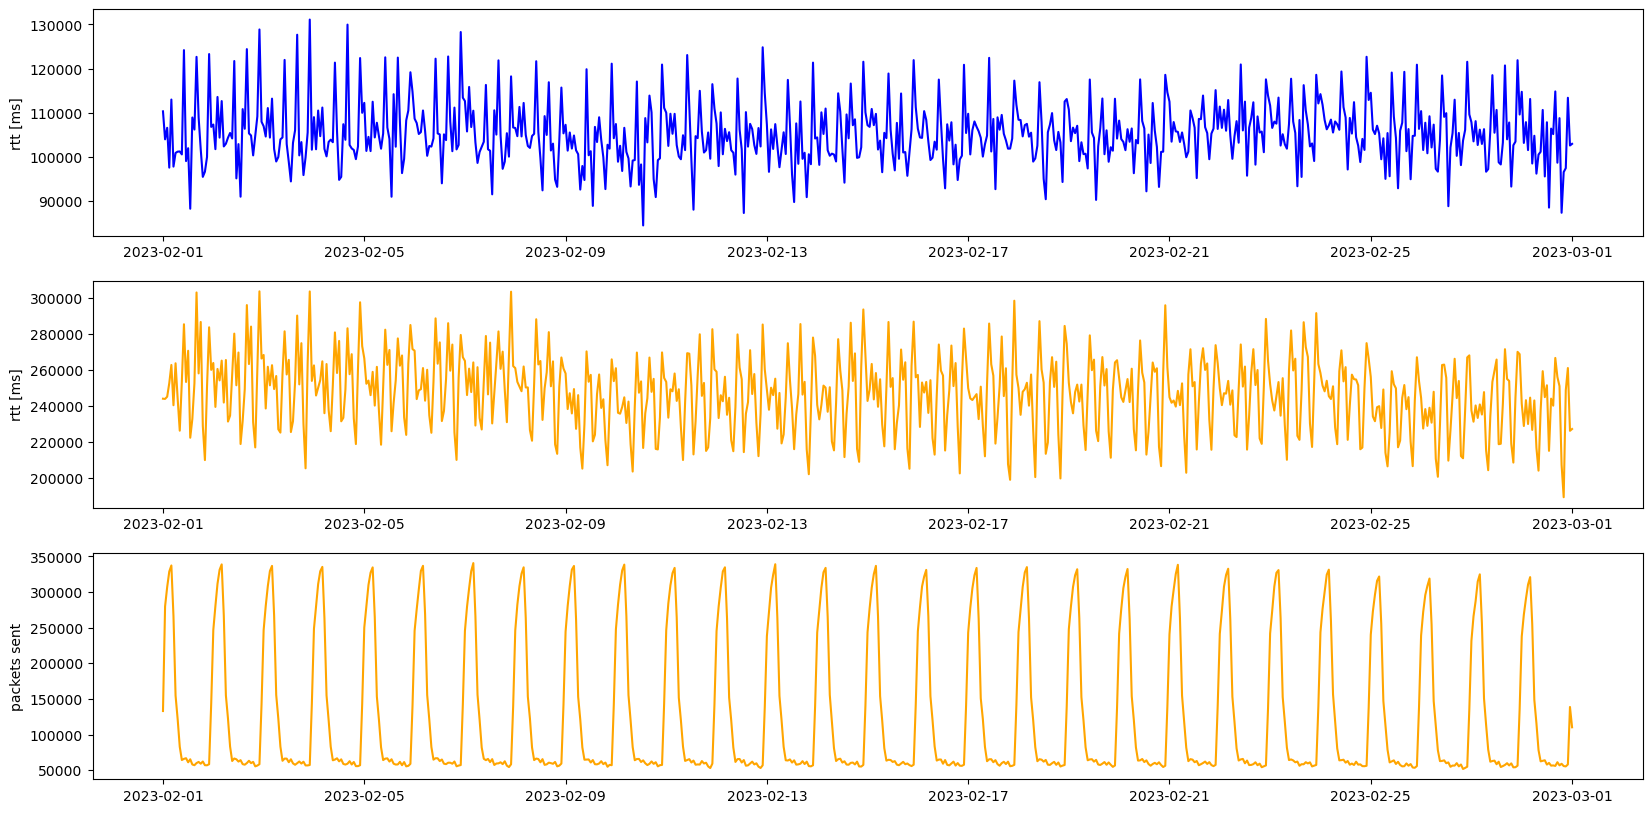

In [30]:
times, dw_rtt, packets_sent, ul_rtt = time_rtt.cast({"dtime" : pl.String}).to_numpy().transpose()

times = times.astype(np.datetime64)

fig, ax = plt.subplots(3, 1,figsize=[20,10])

ax[0].errorbar(times, dw_rtt, color="blue")
ax[0].set_ylabel("rtt [ms]")


ax[1].errorbar(times, ul_rtt, color="orange")
ax[1].set_ylabel("rtt [ms]")

ax[2].errorbar(times, packets_sent, color="orange")
ax[2].set_ylabel("packets sent")

plt.show()

## Linear model

### why:
> ideal when relationships between variables are approximately linear, offering transparent interpretation through coefficients that quantify each feature's impact. It's computationally efficient and serves as a strong baseline for benchmarking more complex models, especially when data meets assumptions like linearity and homoscedasticity. Its simplicity reduces overfitting risks in low-dimensional datasets.

In [31]:
from sklearn import linear_model
linreg = linear_model.LinearRegression()

ins = time_rtt.select(["dtime", "packets_sent", "dw_rtt"]).to_numpy()

linreg.fit(ins, ul_rtt)

lin_score = linreg.score(ins, ul_rtt)

print(f"prediction score r^2 [-1.0:1.0]: {lin_score}")

prediction score r^2 [-1.0:1.0]: 0.5018756323104547


## Gradient boosting

### why
> excels at modeling complex, non-linear patterns by sequentially correcting errors from prior weak learners (typically decision trees), making it highly accurate for heterogeneous or noisy broadband data. It automatically handles feature interactions and allows customization via loss functions (e.g., MAE for robust RTT prediction). While tuning-intensive, its stage-wise training often achieves state-of-the-art performance in regression tasks.

In [32]:
from sklearn.ensemble import GradientBoostingRegressor

gbreg = GradientBoostingRegressor(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=3
)

ins = time_rtt.select(["dtime", "packets_sent", "dw_rtt"]).to_numpy()

gbreg.fit(ins, ul_rtt)


gbreg_score = gbreg.score(ins, ul_rtt)

print(f"prediction score r^2 [-1.0:1.0]: {gbreg_score}")

prediction score r^2 [-1.0:1.0]: 0.8386792071704625


## Random forest regression

### why
> robustly handle non-linear relationships and feature collinearity by aggregating predictions from multiple decorrelated decision trees, reducing overfitting compared to single trees. They provide built-in feature importance scores, helping identify whether download RTT, time, or packets sent dominate upload RTT predictions. Their parallelizable training and inherent noise tolerance make them reliable for real-world network datasets with missing values or outliers.

In [33]:
from sklearn.ensemble import RandomForestRegressor

rfreg = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

ins = time_rtt.select(["dtime", "packets_sent", "dw_rtt"]).to_numpy()

rfreg.fit(ins, ul_rtt)


rfreg_score = rfreg.score(ins, ul_rtt)

print(f"prediction score r^2 [-1.0:1.0]: {rfreg_score}")

prediction score r^2 [-1.0:1.0]: 0.9429336797123073


## Evaluation

In [34]:
lin_prediction_vals = linreg.predict(ins)
gb_prediction_vals = gbreg.predict(ins)
rf_prediction_vals = rfreg.predict(ins)

> presenting a wide overview of raw data and predicted data for the training set (2023)

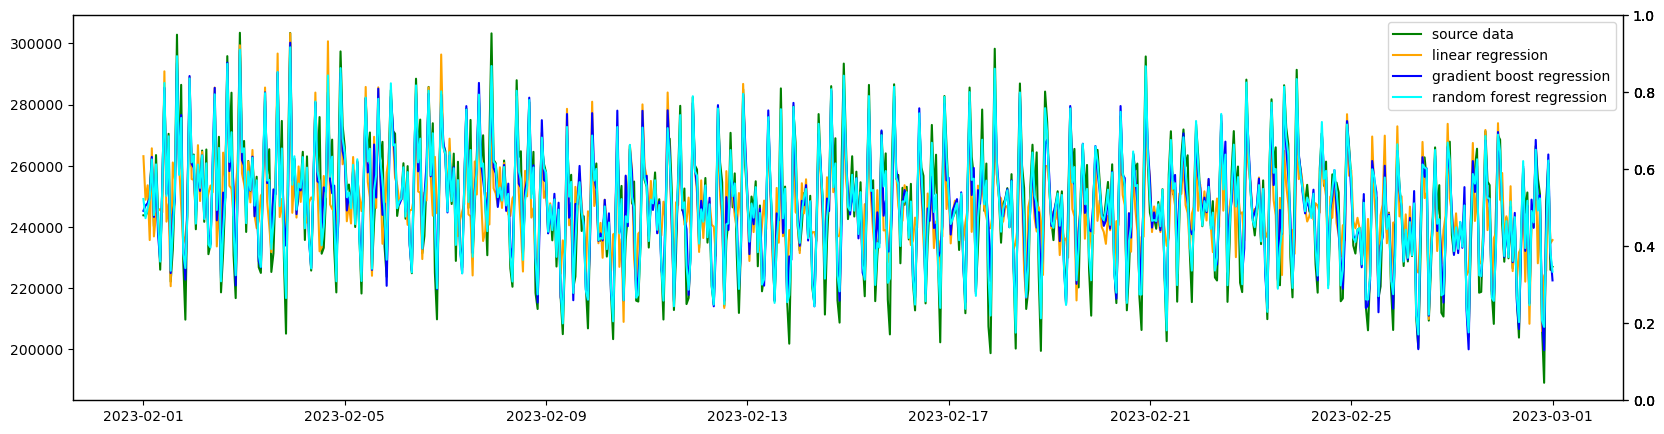

In [35]:
fig, ax = plt.subplots(figsize=[20,5])

ax.errorbar(times, ul_rtt, color="green", label="source data")

axlin = ax.twinx()

axlin = ax.errorbar(times, lin_prediction_vals, color="orange", label="linear regression")

axgb = ax.twinx()

axgb = ax.errorbar(times, gb_prediction_vals, color="blue", label="gradient boost regression")

axrf = ax.twinx()

axrf = ax.errorbar(times, rf_prediction_vals, color="cyan", label="random forest regression")

ax.legend()
plt.show()

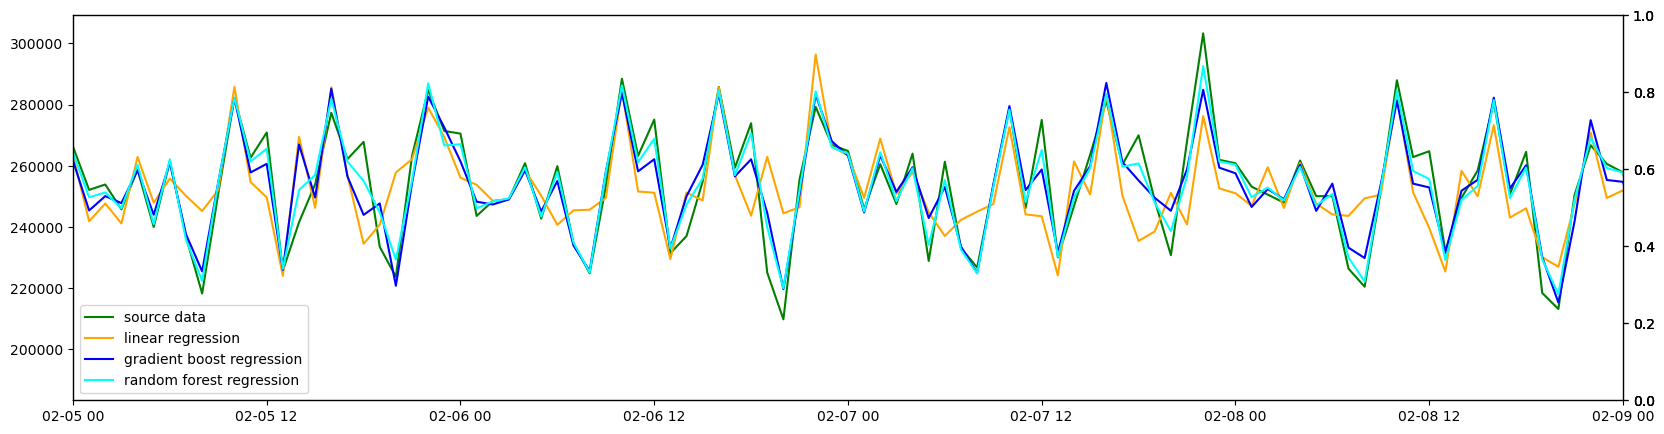

In [36]:
fig, ax = plt.subplots(figsize=[20,5])

ax.errorbar(times, ul_rtt, color="green", label="source data")

ax.set_xlim(np.datetime64("2023-02-05 00:00:00"), np.datetime64("2023-02-09 00:00:00"))

axlin = ax.twinx()

axlin = ax.errorbar(times, lin_prediction_vals, color="orange", label="linear regression")

axgb = ax.twinx()

axgb = ax.errorbar(times, gb_prediction_vals, color="blue", label="gradient boost regression")

axrf = ax.twinx()

axrf = ax.errorbar(times, rf_prediction_vals, color="cyan", label="random forest regression")

ax.legend()
plt.show()

plt.show()

### Comparison

| model | error (2023) | grade |
| --- | --- | --- |
| linear regression | ~0.501 | poor/average |
| gradient boost | ~0.838 | good |
| random forest | ~0.942 | really good |

## Deployment

### reading 2021 data

In [37]:
upload_2021 = pl.read_csv(DATA_2021+"curr_lct_ul.csv")
ul_ping_21 = pl.read_csv(DATA_2021+"curr_ulping.csv")
download_2021 = pl.read_csv(DATA_2021+"curr_lct_dl.csv")

upload_hist_21 = upload_2021.with_columns(pl.col("dtime").str.to_datetime().dt.round("1h"))
upload_hist_21 = upload_hist_21.group_by(["dtime"]).agg(pl.col("packets_sent").sum(), (pl.col("bytes_sec").mean() / 1_000_000).alias("mbytes_sec"), pl.col(["successes", "failures"]).mean() * 100.0).sort(["dtime"])

dwload_hist_21 = download_2021.with_columns(pl.col("dtime").str.to_datetime().dt.round("1h"))
dwload_hist_21 = dwload_hist_21.group_by(["dtime"]).agg(pl.col("packets_sent").sum(), (pl.col("bytes_sec").mean() / 1_000_000).alias("mbytes_sec"), pl.col(["successes", "failures"]).mean() * 100.0).sort(["dtime"])

dw_ping_hist_21 = dl_ping.with_columns(pl.col("dtime").str.to_datetime().dt.round("1h")).group_by("dtime").agg(pl.col("rtt_avg").mean())
dw_hist_21 = dwload_hist_21.join(dw_ping_hist_221, how="left", on="dtime")

ul_ping_hist_21 = ul_ping_21.with_columns(pl.col("dtime").str.to_datetime().dt.round("1h")).group_by("dtime").agg(pl.col("rtt_avg").mean())
ul_hist_21 = upload_hist_21.join(ul_ping_hist_21, how="left", on="dtime")

time_rtt_21 = ul_hist_21.join(dw_hist_21.select(["dtime", pl.col("rtt_avg").alias("dw_rtt")]), how="left", on="dtime").select(["dtime", "dw_rtt", pl.col("^packets.*$"), pl.col("rtt_avg").alias("ul_rtt")])

time_rtt_21

FileNotFoundError: No such file or directory (os error 2): ./data_202102/curr_lct_ul.csv

### Scoring against 2021 data